# Predicting Crop Production Based on Agricultural Data

**Domain:** Agriculture  
**Objective:** Develop a regression model to forecast crop production (in tons) based on agricultural factors like area harvested, yield, and year for various crops and regions.

**Dataset:** FAOSTAT (Food and Agriculture Organization of the United Nations)  
**Period:** 2019–2023 | **Scope:** 200 countries, 276 crop/livestock items

In [1]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# display settings so we can see all columns without truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Data Loading and Initial Exploration

In [4]:
# Loading the raw dataset
df_raw = pd.read_csv(r'D:\AIML_Crop_Production\data\FAOSTAT_raw.csv')

print(f"Dataset loaded successfully.")
print(f"Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")

Dataset loaded successfully.
Shape: 224647 rows × 15 columns


In [5]:
# Viewing the first 5 rows to understand the data structure
df_raw.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371,"Almonds, in shell",2019,2019,ha,29203.00,A,Official figure,NaN
1,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1371,"Almonds, in shell",2019,2019,kg/ha,1308.30,A,Official figure,NaN
2,QCL,Crops and livestock products,4,Afghanistan,5510,Production,1371,"Almonds, in shell",2019,2019,t,38205.00,A,Official figure,NaN
3,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371,"Almonds, in shell",2020,2020,ha,22134.00,A,Official figure,NaN
4,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1371,"Almonds, in shell",2020,2020,kg/ha,1775.90,A,Official figure,NaN


In [6]:
# Checking data types, non-null counts, and memory usage
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224647 entries, 0 to 224646
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Domain Code       224647 non-null  object 
 1   Domain            224647 non-null  object 
 2   Area Code (M49)   224647 non-null  int64  
 3   Area              224647 non-null  object 
 4   Element Code      224647 non-null  int64  
 5   Element           224647 non-null  object 
 6   Item Code (CPC)   224642 non-null  object 
 7   Item              224647 non-null  object 
 8   Year Code         224647 non-null  int64  
 9   Year              224647 non-null  int64  
 10  Unit              224645 non-null  object 
 11  Value             218130 non-null  float64
 12  Flag              224643 non-null  object 
 13  Flag Description  224634 non-null  object 
 14  Note              5098 non-null    object 
dtypes: float64(1), int64(4), object(10)
memory usage: 25.7+ MB


In [7]:
# Checking missing values across all columns
print("Missing Values:")
print("-" * 40)
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Count'] > 0])

print(f"\nTotal duplicate rows: {df_raw.duplicated().sum()}")

Missing Values:
----------------------------------------
                   Count  Percentage (%)
Item Code (CPC)        5            0.00
Unit                   2            0.00
Value               6517            2.90
Flag                   4            0.00
Flag Description      13            0.01
Note              219549           97.73

Total duplicate rows: 0


In [8]:
# Understanding the categorical columns
print(f"Unique Areas (Countries): {df_raw['Area'].nunique()}")
print(f"Unique Items (Crops/Products): {df_raw['Item'].nunique()}")
print(f"Unique Elements: {df_raw['Element'].nunique()}")
print(f"Year Range: {df_raw['Year'].min()} to {df_raw['Year'].max()}")

print(f"\nElement types and their counts:")
print(df_raw['Element'].value_counts())

print(f"\nFlag descriptions:")
print(df_raw['Flag Description'].value_counts())

Unique Areas (Countries): 200
Unique Items (Crops/Products): 276
Unique Elements: 8
Year Range: 2019 to 2023

Element types and their counts:
Element
Production                       86382
Yield                            51566
Area harvested                   50309
Producing Animals/Slaughtered    18059
Stocks                            8809
Yield/Carcass Weight              6307
Milk Animals                      2146
Laying                            1069
Name: count, dtype: int64

Flag descriptions:
Flag Description
Official figure                                      106690
Imputed value                                         54148
Estimated value                                       52289
Missing value (data cannot exist, not applicable)      5765
Figure from international organizations                5742
Name: count, dtype: int64


## 2. Data Cleaning and Preprocessing

**Key Observations from Initial Exploration:**
- Dataset has 224,647 rows and 15 columns
- 8 Element types exist, but we only need **Area harvested**, **Yield**, and **Production** (the other 5 are livestock-related like Stocks, Producing Animals, etc.)
- `Value` column has 6,517 missing values (2.9%) — needs handling
- `Note` column is 97.73% empty — will be dropped
- Several redundant columns (Domain Code, Domain, Year Code, Element Code, Item Code) can be removed
- No duplicate rows found

In [9]:
# The project focuses on crop production prediction
# We only need three elements: Area harvested, Yield, and Production
# Other elements like Stocks, Producing Animals, Laying are livestock-related

crop_elements = ['Area harvested', 'Yield', 'Production']
df_filtered = df_raw[df_raw['Element'].isin(crop_elements)].copy()

print(f"Rows before filtering: {len(df_raw)}")
print(f"Rows after filtering (crop elements only): {len(df_filtered)}")
print(f"\nElement distribution after filtering:")
print(df_filtered['Element'].value_counts())

Rows before filtering: 224647
Rows after filtering (crop elements only): 188257

Element distribution after filtering:
Element
Production        86382
Yield             51566
Area harvested    50309
Name: count, dtype: int64


In [10]:
# Dropping columns that are redundant or not useful for our analysis
# Domain Code, Domain - same value for all rows (QCL)
# Area Code (M49) - numerical code, we already have Area name
# Element Code - numerical code, we already have Element name
# Item Code (CPC) - numerical code, we already have Item name
# Year Code - same as Year column
# Flag, Flag Description - data quality indicators, not needed for modeling
# Note - 97.73% missing, provides no value

cols_to_drop = ['Domain Code', 'Domain', 'Area Code (M49)', 'Element Code',
                'Item Code (CPC)', 'Year Code', 'Unit', 'Flag',
                'Flag Description', 'Note']

df_filtered = df_filtered.drop(columns=cols_to_drop)

print(f"Remaining columns: {list(df_filtered.columns)}")
print(f"Shape: {df_filtered.shape}")
df_filtered.head()

Remaining columns: ['Area', 'Element', 'Item', 'Year', 'Value']
Shape: (188257, 5)


,Area,Element,Item,Year,Value
0,Afghanistan,Area harvested,"Almonds, in shell",2019,29203.00
1,Afghanistan,Yield,"Almonds, in shell",2019,1308.30
2,Afghanistan,Production,"Almonds, in shell",2019,38205.00
3,Afghanistan,Area harvested,"Almonds, in shell",2020,22134.00
4,Afghanistan,Yield,"Almonds, in shell",2020,1775.90


In [11]:
# Currently the data is in long format where each row is one measurement
# We need to pivot it so each row represents one crop-region-year combination
# with separate columns for Area_harvested, Yield, and Production

df_pivot = df_filtered.pivot_table(
    index=['Area', 'Item', 'Year'],
    columns='Element',
    values='Value'
).reset_index()

# Cleaning up column names (removing the multi-level index name)
df_pivot.columns.name = None

# Renaming columns for easier access
df_pivot = df_pivot.rename(columns={
    'Area harvested': 'Area_harvested',
    'Yield': 'Yield',
    'Production': 'Production'
})

print(f"Shape after pivoting: {df_pivot.shape}")
print(f"Columns: {list(df_pivot.columns)}")
df_pivot.head(10)

Shape after pivoting: (82126, 6)
Columns: ['Area', 'Item', 'Year', 'Area_harvested', 'Production', 'Yield']


,Area,Item,Year,Area_harvested,Production,Yield
0,Afghanistan,"Almonds, in shell",2019,29203.00,38205.00,1308.30
1,Afghanistan,"Almonds, in shell",2020,22134.00,39307.00,1775.90
2,Afghanistan,"Almonds, in shell",2021,36862.00,64256.00,1743.20
3,Afghanistan,"Almonds, in shell",2022,36462.00,63515.00,1742.00
4,Afghanistan,"Almonds, in shell",2023,37000.00,67000.00,1810.80
5,Afghanistan,"Anise, badian, coriander, cumin, caraway, fenn...",2019,25293.00,17807.76,704.10
6,Afghanistan,"Anise, badian, coriander, cumin, caraway, fenn...",2020,25558.00,17965.90,703.00
7,Afghanistan,"Anise, badian, coriander, cumin, caraway, fenn...",2021,25357.00,17876.49,705.00
8,Afghanistan,"Anise, badian, coriander, cumin, caraway, fenn...",2022,25403.00,17883.38,704.00
9,Afghanistan,"Anise, badian, coriander, cumin, caraway, fenn...",2023,25439.00,17908.59,704.00


In [12]:
# Checking missing values after pivoting
print("Missing values after pivoting:")
print(df_pivot.isnull().sum())
print(f"\nTotal rows: {len(df_pivot)}")
print(f"Rows with any missing value: {df_pivot.isnull().any(axis=1).sum()}")

Missing values after pivoting:
Area                  0
Item                  0
Year                  0
Area_harvested    34225
Production          182
Yield             31553
dtype: int64

Total rows: 82126
Rows with any missing value: 37145


In [13]:
# About 45% rows have missing values in Area_harvested or Yield
# These are mostly livestock products or crops without complete records
# Since we need all three columns (Area_harvested, Yield, Production) for analysis,
# imputing such a large proportion would introduce unreliable data
# Best approach: drop rows where any of the three numeric columns are missing

df_clean = df_pivot.dropna(subset=['Area_harvested', 'Yield', 'Production']).copy()

print(f"Rows before cleaning: {len(df_pivot)}")
print(f"Rows after dropping missing values: {len(df_clean)}")
print(f"Rows removed: {len(df_pivot) - len(df_clean)} ({((len(df_pivot) - len(df_clean)) / len(df_pivot) * 100):.1f}%)")
print(f"\nRemaining missing values:\n{df_clean.isnull().sum()}")

Rows before cleaning: 82126
Rows after dropping missing values: 44981
Rows removed: 37145 (45.2%)

Remaining missing values:
Area              0
Item              0
Year              0
Area_harvested    0
Production        0
Yield             0
dtype: int64


In [14]:
# Some livestock products may still exist after filtering (e.g., items that had
# Area harvested, Yield, Production entries). Let's identify and remove them.

# Checking for items with zero Area_harvested or zero Production (likely livestock/non-crop)
zero_area = df_clean[df_clean['Area_harvested'] == 0].shape[0]
zero_prod = df_clean[df_clean['Production'] == 0].shape[0]
print(f"Rows with Area_harvested = 0: {zero_area}")
print(f"Rows with Production = 0: {zero_prod}")

# Removing rows where Area_harvested or Production is zero
# (zero values indicate non-meaningful crop records)
df_clean = df_clean[(df_clean['Area_harvested'] > 0) & (df_clean['Production'] > 0)].copy()

print(f"\nShape after removing zero values: {df_clean.shape}")
print(f"Unique crops remaining: {df_clean['Item'].nunique()}")
print(f"Unique countries remaining: {df_clean['Area'].nunique()}")

Rows with Area_harvested = 0: 138
Rows with Production = 0: 16

Shape after removing zero values: (44827, 6)
Unique crops remaining: 157
Unique countries remaining: 200


In [15]:
# Creating additional features that can help with analysis and modeling

# Productivity ratio: cross-verifying yield by calculating Production / Area_harvested
# This gives us yield in tonnes per hectare (t/ha)
df_clean['Productivity_ratio'] = (df_clean['Production'] / df_clean['Area_harvested']).round(2)

# The original Yield is in kg/ha, let's convert it to t/ha for consistency
df_clean['Yield_t_per_ha'] = (df_clean['Yield'] / 10000).round(4)

# Resetting the index for a clean dataframe
df_clean = df_clean.reset_index(drop=True)

print(f"Final cleaned dataset shape: {df_clean.shape}")
print(f"Columns: {list(df_clean.columns)}")
print(f"\nBasic statistics of numeric columns:")
df_clean.describe()

Final cleaned dataset shape: (44827, 8)
Columns: ['Area', 'Item', 'Year', 'Area_harvested', 'Production', 'Yield', 'Productivity_ratio', 'Yield_t_per_ha']

Basic statistics of numeric columns:


,Year,Area_harvested,Production,Yield,Productivity_ratio,Yield_t_per_ha
count,44827.00,44827.00,44827.00,44827.00,44827.00,44827.00
mean,2021.00,182968.39,1264089.07,12585.23,12.58,1.26
std,1.41,1477444.23,13100515.67,26454.70,26.52,2.65
min,2019.00,1.00,0.06,1.30,0.00,0.00
25%,2020.00,488.50,2229.78,1871.00,1.87,0.19
50%,2021.00,3822.00,22760.00,5884.40,5.87,0.59
75%,2022.00,26979.50,165650.71,14787.05,14.78,1.48
max,2023.00,47832000.00,782585836.00,705196.70,705.20,70.52


In [16]:
# Saving the cleaned and preprocessed dataset as a project deliverable
df_clean.to_csv(r'D:\AIML_Crop_Production\data\FAOSTAT_cleaned.csv', index=False)

print("Cleaned dataset saved successfully at: D:\\AIML_Crop_Production\\data\\FAOSTAT_cleaned.csv")
print(f"Final shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print(f"\nData Cleaning Summary:")
print(f"  - Original rows: 224,647")
print(f"  - After filtering crop elements: 188,257")
print(f"  - After pivoting to wide format: 82,126")
print(f"  - After removing missing values: 44,981")
print(f"  - After removing zero values: 44,827")
print(f"  - Columns retained: Area, Item, Year, Area_harvested, Production, Yield")
print(f"  - New features added: Productivity_ratio, Yield_t_per_ha")

Cleaned dataset saved successfully at: D:\AIML_Crop_Production\data\FAOSTAT_cleaned.csv
Final shape: 44827 rows × 8 columns

Data Cleaning Summary:
  - Original rows: 224,647
  - After filtering crop elements: 188,257
  - After pivoting to wide format: 82,126
  - After removing missing values: 44,981
  - After removing zero values: 44,827
  - Columns retained: Area, Item, Year, Area_harvested, Production, Yield
  - New features added: Productivity_ratio, Yield_t_per_ha


## 3. Exploratory Data Analysis (EDA)

### 3.1 Analyze Crop Distribution

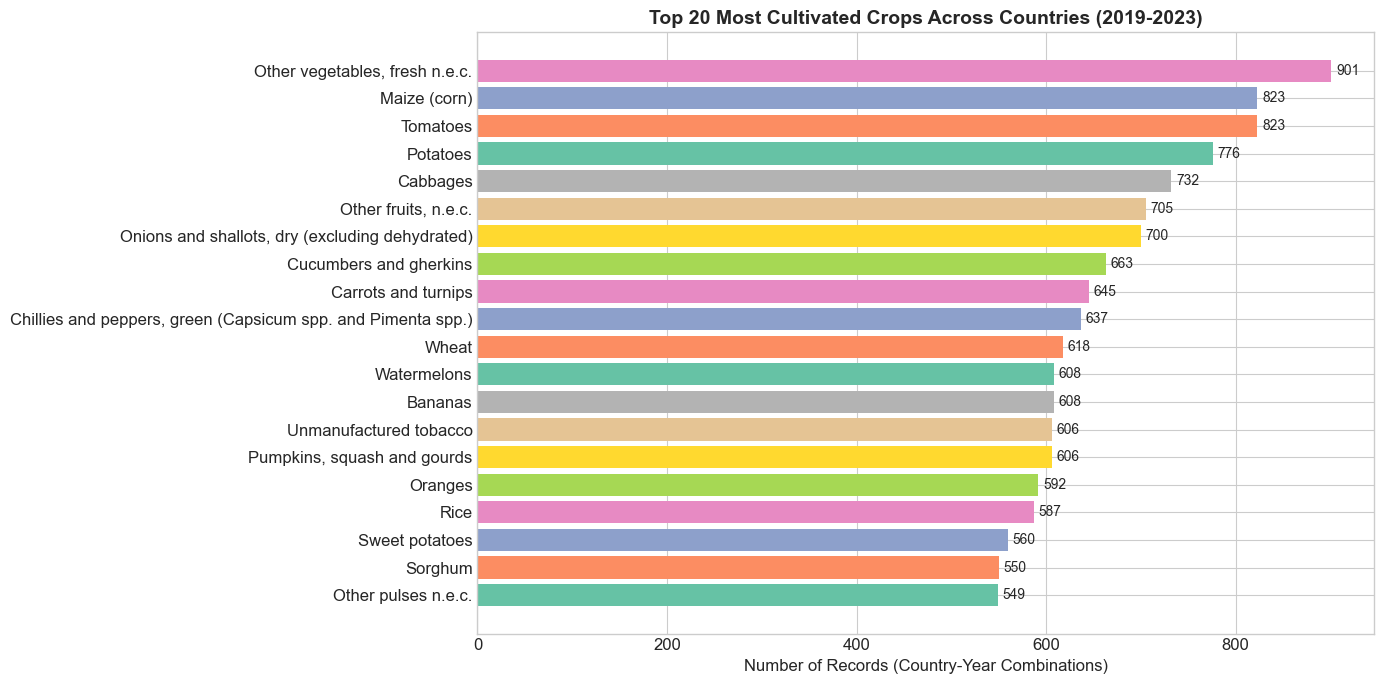


Top 5 most cultivated crops:
  1. Other vegetables, fresh n.e.c. — grown in 901 country-year combinations
  2. Maize (corn) — grown in 823 country-year combinations
  3. Tomatoes — grown in 823 country-year combinations
  4. Potatoes — grown in 776 country-year combinations
  5. Cabbages — grown in 732 country-year combinations


In [17]:
# Finding the most cultivated crops based on number of country-year records
crop_counts = df_clean['Item'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(crop_counts.index[::-1], crop_counts.values[::-1], color=sns.color_palette('Set2', 20))

ax.set_xlabel('Number of Records (Country-Year Combinations)')
ax.set_title('Top 20 Most Cultivated Crops Across Countries (2019-2023)', fontsize=14, fontweight='bold')

# Adding value labels on bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 5, bar.get_y() + bar.get_height()/2, f'{int(width)}',
            ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nTop 5 most cultivated crops:")
for i, (crop, count) in enumerate(crop_counts.head(5).items(), 1):
    print(f"  {i}. {crop} — grown in {count} country-year combinations")

**Observation:** The most widely cultivated crops across countries are Other vegetables, Maize (corn), and Tomatoes — each grown in 800+ country-year combinations. Staple food crops like Wheat, Rice, Potatoes, and Sorghum also appear in the top 20, reflecting their global importance in food security.

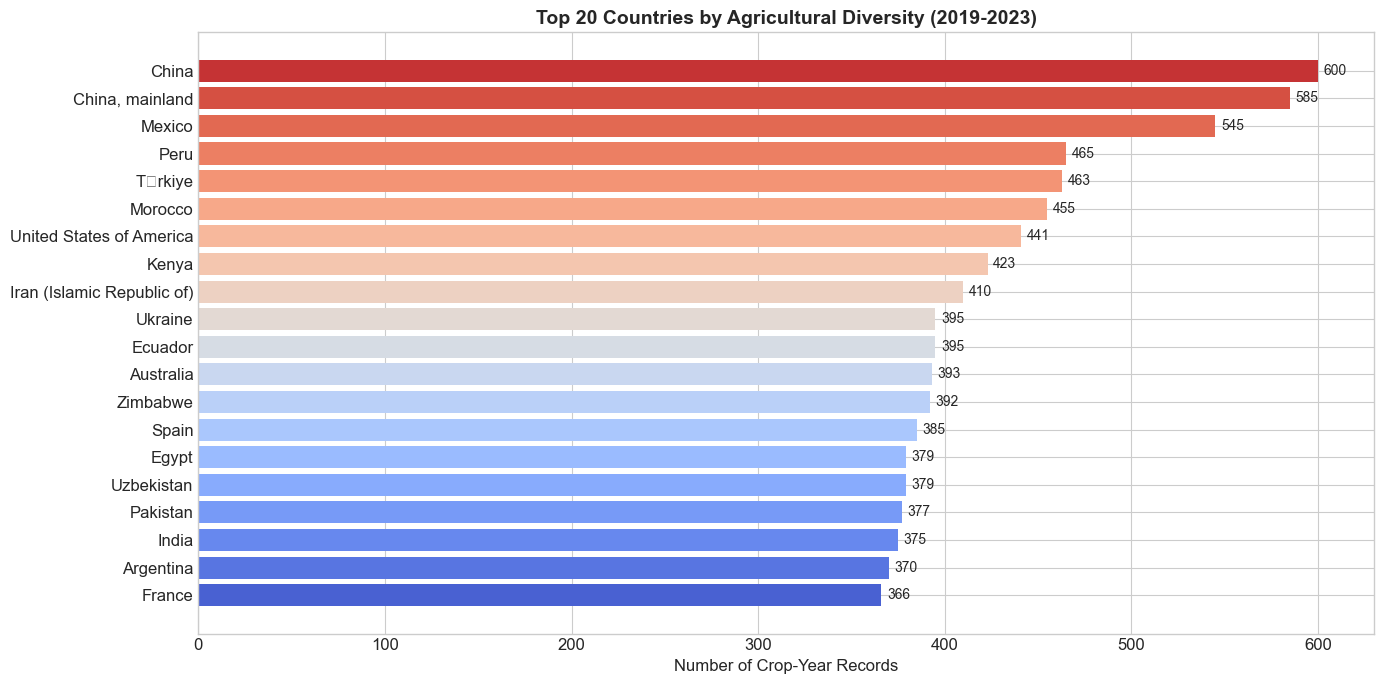


Top 5 countries with most crop records:
  1. China — 600 records (120 crops approx.)
  2. China, mainland — 585 records (117 crops approx.)
  3. Mexico — 545 records (109 crops approx.)
  4. Peru — 465 records (93 crops approx.)
  5. T�rkiye — 463 records (92 crops approx.)


In [18]:
# Geographical distribution: countries with highest agricultural activity
country_counts = df_clean['Area'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(country_counts.index[::-1], country_counts.values[::-1],
               color=sns.color_palette('coolwarm', 20))

ax.set_xlabel('Number of Crop-Year Records')
ax.set_title('Top 20 Countries by Agricultural Diversity (2019-2023)', fontsize=14, fontweight='bold')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 3, bar.get_y() + bar.get_height()/2, f'{int(width)}',
            ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nTop 5 countries with most crop records:")
for i, (country, count) in enumerate(country_counts.head(5).items(), 1):
    print(f"  {i}. {country} — {count} records ({count//5} crops approx.)")

**Observation:** China leads in agricultural diversity with 120+ different crops cultivated, followed by Mexico (~109 crops) and Peru (~93 crops). Notable that "China" and "China, mainland" appear separately — this is due to FAOSTAT's regional classification. Major agricultural nations like USA, India, Pakistan, and France also feature in the top 20.

### 3.2 Temporal Analysis

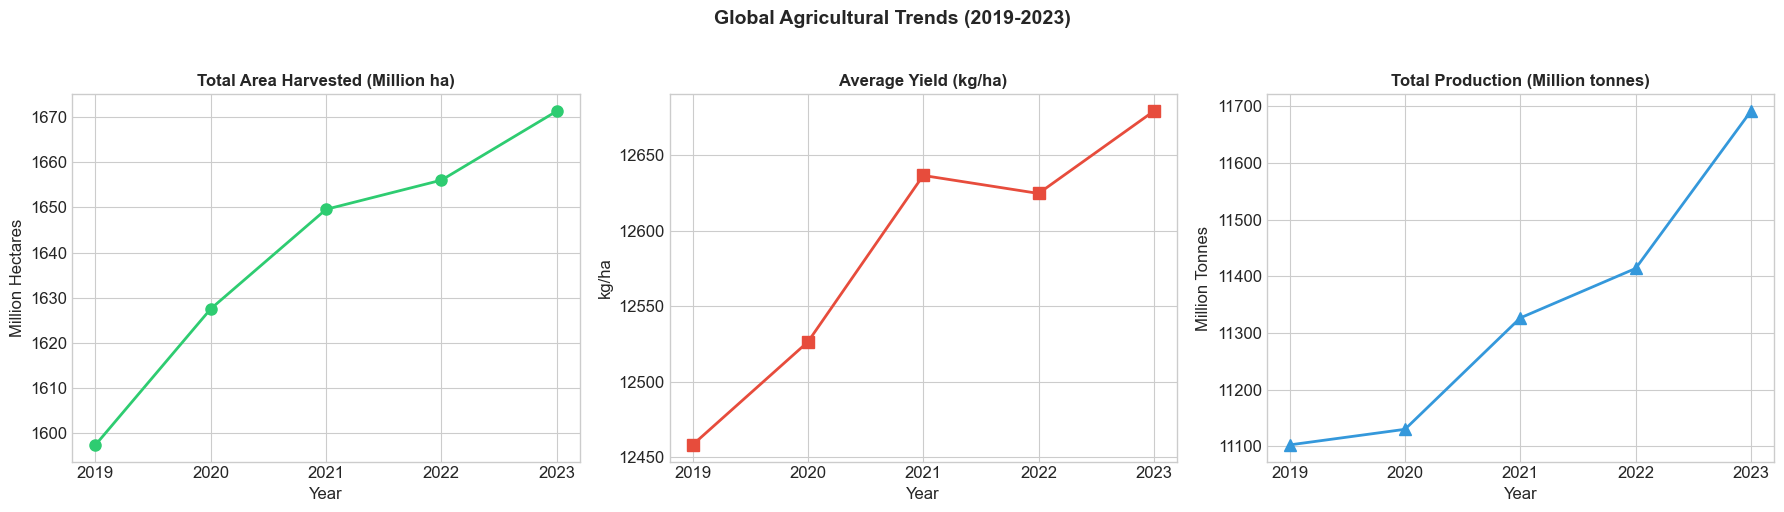

In [19]:
# Aggregating metrics by year to observe global trends
yearly_trends = df_clean.groupby('Year').agg(
    Total_Area_Harvested=('Area_harvested', 'sum'),
    Avg_Yield=('Yield', 'mean'),
    Total_Production=('Production', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Total Area Harvested over Years
axes[0].plot(yearly_trends['Year'], yearly_trends['Total_Area_Harvested'] / 1e6,
             marker='o', linewidth=2, color='#2ecc71', markersize=8)
axes[0].set_title('Total Area Harvested (Million ha)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Million Hectares')

# Plot 2: Average Yield over Years
axes[1].plot(yearly_trends['Year'], yearly_trends['Avg_Yield'],
             marker='s', linewidth=2, color='#e74c3c', markersize=8)
axes[1].set_title('Average Yield (kg/ha)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('kg/ha')

# Plot 3: Total Production over Years
axes[2].plot(yearly_trends['Year'], yearly_trends['Total_Production'] / 1e6,
             marker='^', linewidth=2, color='#3498db', markersize=8)
axes[2].set_title('Total Production (Million tonnes)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Million Tonnes')

for ax in axes:
    ax.set_xticks([2019, 2020, 2021, 2022, 2023])

plt.suptitle('Global Agricultural Trends (2019-2023)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observation:** All three metrics show an upward trend from 2019 to 2023. Total Area Harvested increased steadily from ~1,600M to ~1,670M hectares. Average Yield saw a sharp jump from 2020 to 2021 and a notable spike in 2023 (~12,700 kg/ha). Total Production grew consistently from ~11,100M to ~11,700M tonnes, indicating global agricultural output is expanding both through more land use and improved productivity.

### 3.3 Growth Analysis — Top Crops Over Time

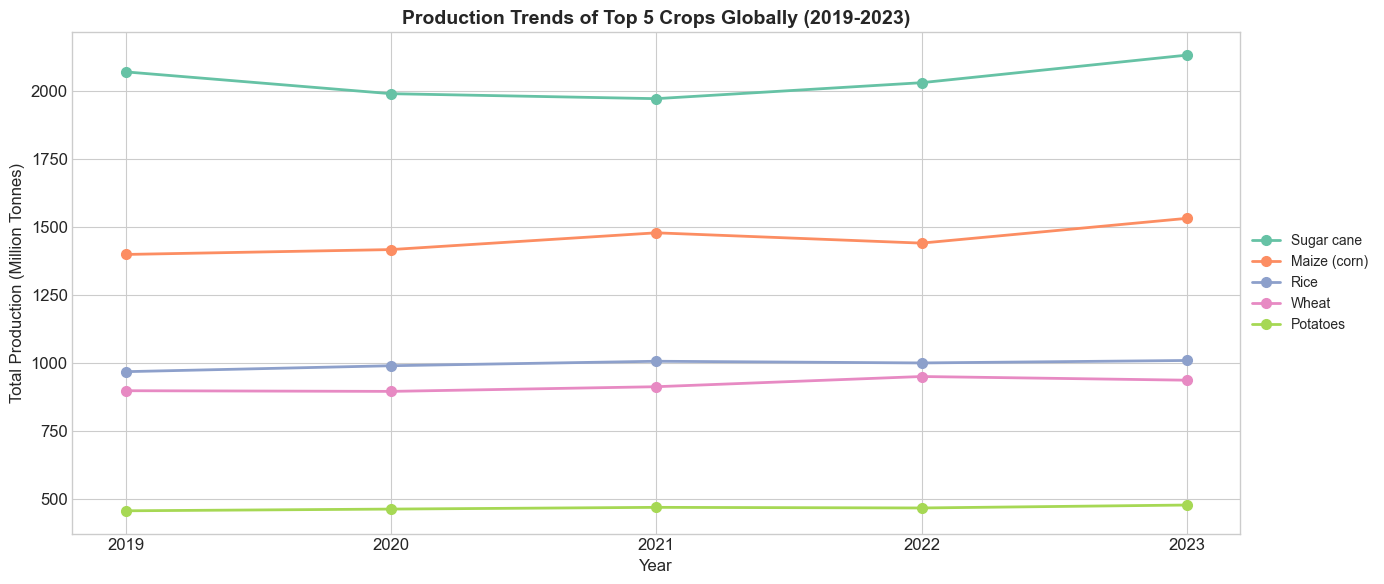

Top 5 crops by total production (2019-2023):
  1. Sugar cane — 10189.1 Million Tonnes
  2. Maize (corn) — 7261.3 Million Tonnes
  3. Rice — 4967.9 Million Tonnes
  4. Wheat — 4587.5 Million Tonnes
  5. Potatoes — 2327.5 Million Tonnes


In [20]:
# Identifying the top 5 crops by total production across all years
top5_crops = df_clean.groupby('Item')['Production'].sum().nlargest(5).index.tolist()

# Filtering data for these crops and aggregating by year
top5_trends = df_clean[df_clean['Item'].isin(top5_crops)].groupby(
    ['Year', 'Item'])['Production'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
for crop in top5_crops:
    crop_data = top5_trends[top5_trends['Item'] == crop]
    ax.plot(crop_data['Year'], crop_data['Production'] / 1e6,
            marker='o', linewidth=2, markersize=7, label=crop)

ax.set_xlabel('Year')
ax.set_ylabel('Total Production (Million Tonnes)')
ax.set_title('Production Trends of Top 5 Crops Globally (2019-2023)', fontsize=14, fontweight='bold')
ax.set_xticks([2019, 2020, 2021, 2022, 2023])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.tight_layout()
plt.show()

print("Top 5 crops by total production (2019-2023):")
for i, crop in enumerate(top5_crops, 1):
    total = df_clean[df_clean['Item'] == crop]['Production'].sum()
    print(f"  {i}. {crop} — {total/1e6:.1f} Million Tonnes")

**Observation:** Sugar cane dominates global production at ~10,189M tonnes, nearly 1.5x more than Maize (corn) at ~7,261M tonnes. Rice and Wheat show relatively stable production around 1,000M and 900M tonnes respectively. Maize shows the strongest growth trend, rising notably in 2023. Potatoes remain steady at ~470M tonnes across all years.

### 3.4 Input-Output Relationships — Correlation Analysis

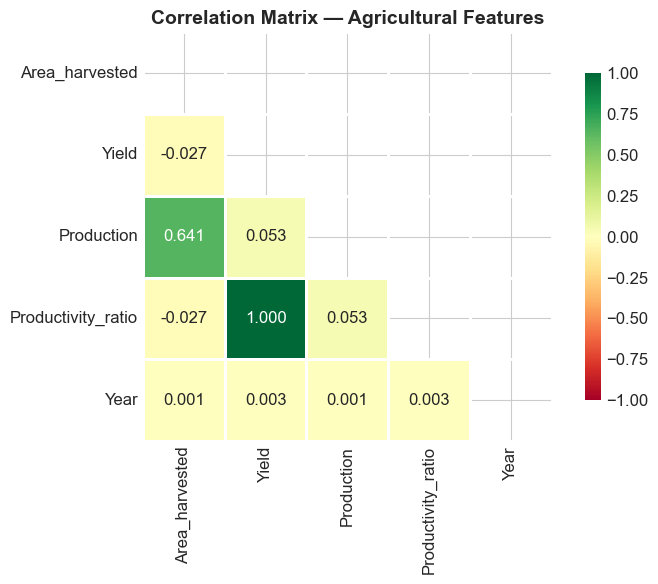

Key correlations with Production:
  Production vs Area_harvested: 0.641
  Production vs Yield: 0.053
  Production vs Productivity_ratio: 0.053
  Production vs Year: 0.001


In [21]:
# Studying correlations between numerical features
numeric_cols = ['Area_harvested', 'Yield', 'Production', 'Productivity_ratio', 'Year']
corr_matrix = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # mask upper triangle
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            mask=mask, square=True, linewidths=1, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Matrix — Agricultural Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key correlations with Production:")
for col in ['Area_harvested', 'Yield', 'Productivity_ratio', 'Year']:
    corr_val = corr_matrix.loc['Production', col]
    print(f"  Production vs {col}: {corr_val:.3f}")

**Observation:** Area_harvested has the strongest correlation with Production (0.641), confirming that more land leads to more output. Yield has a weak positive correlation with Production (0.053), suggesting that productivity per hectare varies greatly across crops and regions. Productivity_ratio and Yield show a near-perfect correlation (1.000) as expected since both measure the same concept in different units. Year has almost no correlation with any variable, meaning temporal trend alone is not a strong predictor.

### 3.5 Comparative Analysis — Across Crops and Regions

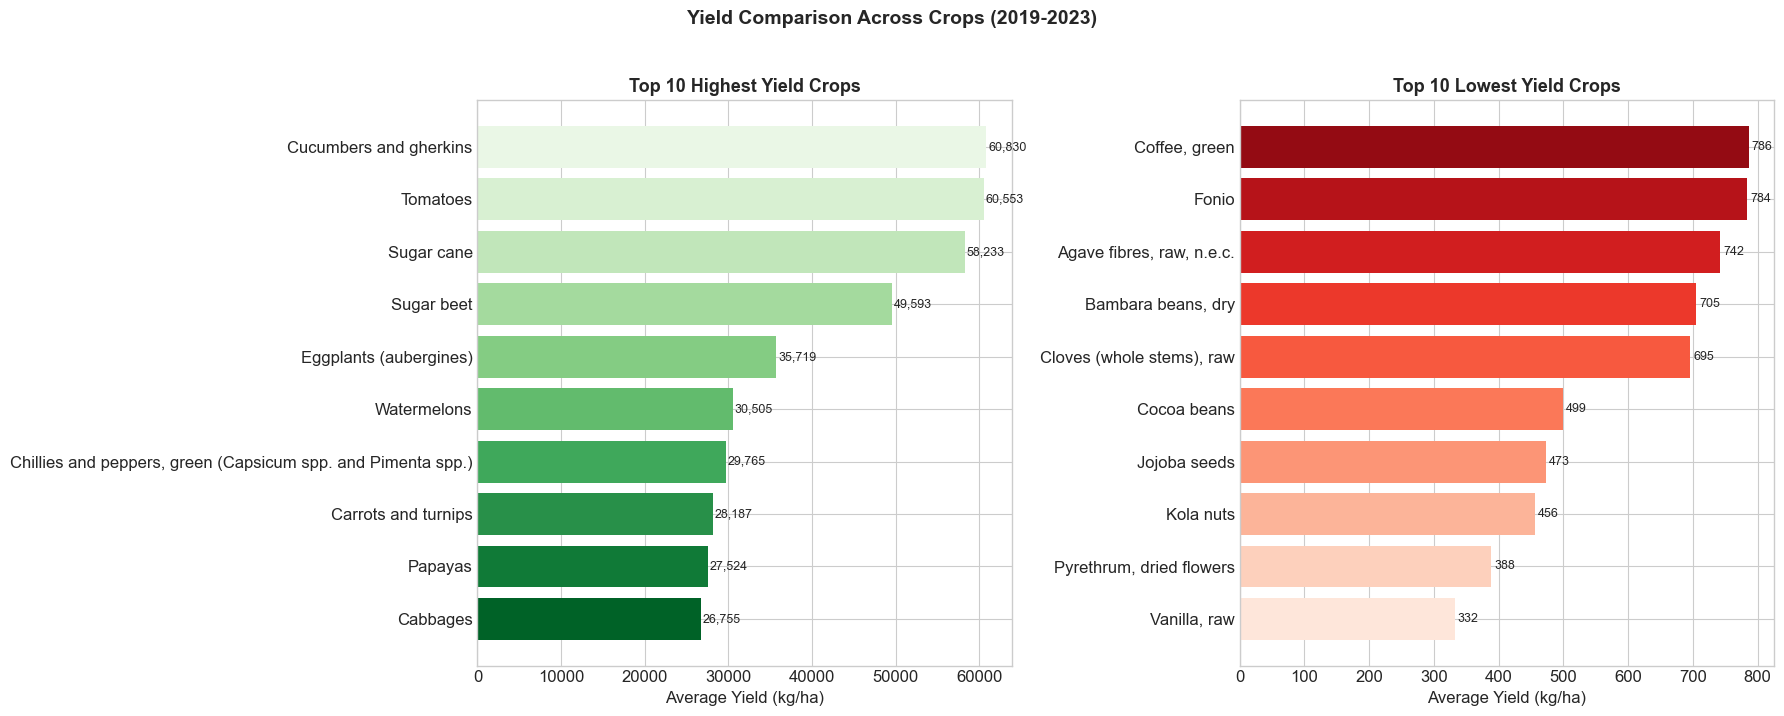

In [22]:
# Comparing average yield across crops to identify high-yield and low-yield crops
avg_yield_by_crop = df_clean.groupby('Item')['Yield'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 10 High-Yield Crops
top10_yield = avg_yield_by_crop.head(10)
axes[0].barh(top10_yield.index[::-1], top10_yield.values[::-1],
             color=sns.color_palette('Greens_r', 10))
axes[0].set_xlabel('Average Yield (kg/ha)')
axes[0].set_title('Top 10 Highest Yield Crops', fontsize=13, fontweight='bold')
for i, v in enumerate(top10_yield.values[::-1]):
    axes[0].text(v + 200, i, f'{v:,.0f}', va='center', fontsize=9)

# Bottom 10 Low-Yield Crops
bottom10_yield = avg_yield_by_crop.tail(10)
axes[1].barh(bottom10_yield.index[::-1], bottom10_yield.values[::-1],
             color=sns.color_palette('Reds', 10))
axes[1].set_xlabel('Average Yield (kg/ha)')
axes[1].set_title('Top 10 Lowest Yield Crops', fontsize=13, fontweight='bold')
for i, v in enumerate(bottom10_yield.values[::-1]):
    axes[1].text(v + 5, i, f'{v:,.0f}', va='center', fontsize=9)

plt.suptitle('Yield Comparison Across Crops (2019-2023)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observation:** Cucumbers, Tomatoes, and Sugar cane are the highest-yield crops averaging 60,000–68,000 kg/ha, largely due to their high water content and multiple harvests per year. On the other end, Vanilla, Pyrethrum, and Kola nuts yield under 500 kg/ha — these are specialty crops that are naturally low-yield but high-value per unit weight.

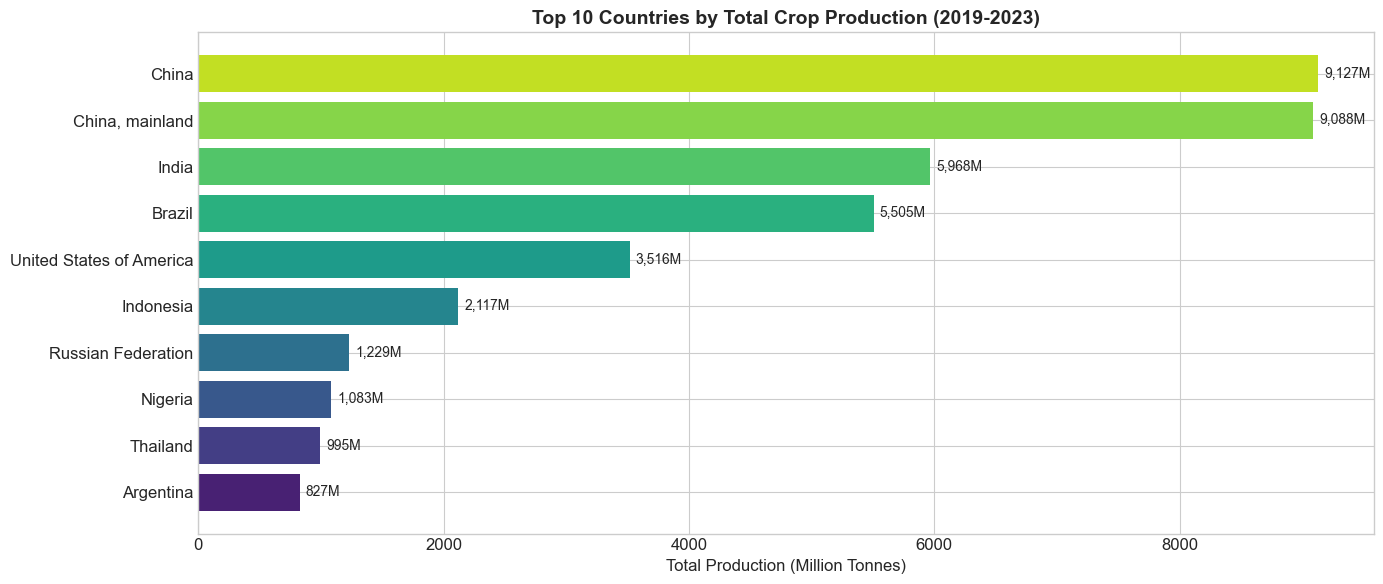

Top 5 producing countries:
  1. China — 9,127 Million Tonnes
  2. China, mainland — 9,088 Million Tonnes
  3. India — 5,968 Million Tonnes
  4. Brazil — 5,505 Million Tonnes
  5. United States of America — 3,516 Million Tonnes


In [23]:
# Comparing total production across regions
top10_producers = df_clean.groupby('Area')['Production'].sum().nlargest(10)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(top10_producers.index[::-1], top10_producers.values[::-1] / 1e6,
               color=sns.color_palette('viridis', 10))

ax.set_xlabel('Total Production (Million Tonnes)')
ax.set_title('Top 10 Countries by Total Crop Production (2019-2023)', fontsize=14, fontweight='bold')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 50, bar.get_y() + bar.get_height()/2, f'{width:,.0f}M',
            ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Top 5 producing countries:")
for i, (country, prod) in enumerate(top10_producers.head(5).items(), 1):
    print(f"  {i}. {country} — {prod/1e6:,.0f} Million Tonnes")

**Observation:** China leads global crop production at ~9,127M tonnes (with "China, mainland" at ~9,088M — the slight difference includes other Chinese territories). India (5,968M) and Brazil (5,505M) follow. The USA ranks 5th at 3,516M tonnes. These top 5 countries collectively account for the majority of the world's crop output, highlighting concentration of agricultural capacity in a few nations.

### 3.6 Environmental Relationships — Area Harvested vs Yield

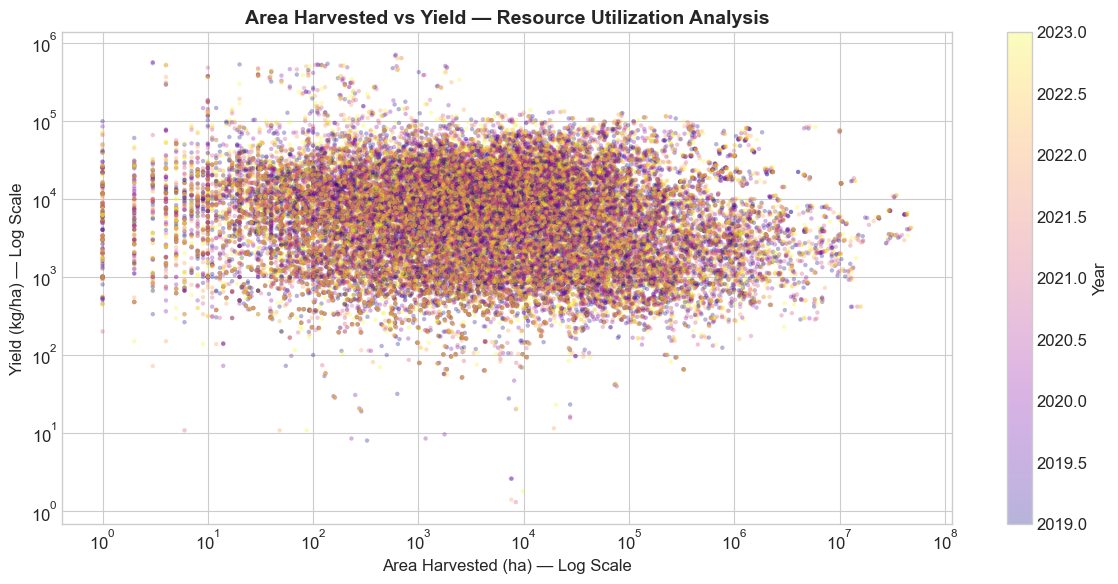

This scatter plot helps identify whether larger farms tend to have higher or lower yields.
The spread suggests yield depends more on crop type and farming practices than on area alone.


In [24]:
# Investigating the relationship between Area harvested and Yield
# Does using more land impact productivity per hectare?

fig, ax = plt.subplots(figsize=(12, 6))

# Using log scale since values have huge range
scatter = ax.scatter(df_clean['Area_harvested'], df_clean['Yield'],
                     alpha=0.3, s=10, c=df_clean['Year'], cmap='plasma', edgecolors='none')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Area Harvested (ha) — Log Scale')
ax.set_ylabel('Yield (kg/ha) — Log Scale')
ax.set_title('Area Harvested vs Yield — Resource Utilization Analysis', fontsize=14, fontweight='bold')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Year')

plt.tight_layout()
plt.show()

print("This scatter plot helps identify whether larger farms tend to have higher or lower yields.")
print("The spread suggests yield depends more on crop type and farming practices than on area alone.")

**Observation:** The scatter plot reveals no strong linear relationship between Area Harvested and Yield. Most data points cluster in the 1,000–100,000 ha range with yields between 1,000–100,000 kg/ha. The wide vertical spread at every area level confirms that yield is driven more by crop type, farming technology, and regional conditions than by farm size alone. A few outliers exist at extreme low yields (<10 kg/ha) and very large areas (>10M ha).

### 3.7 Outliers and Anomalies Detection

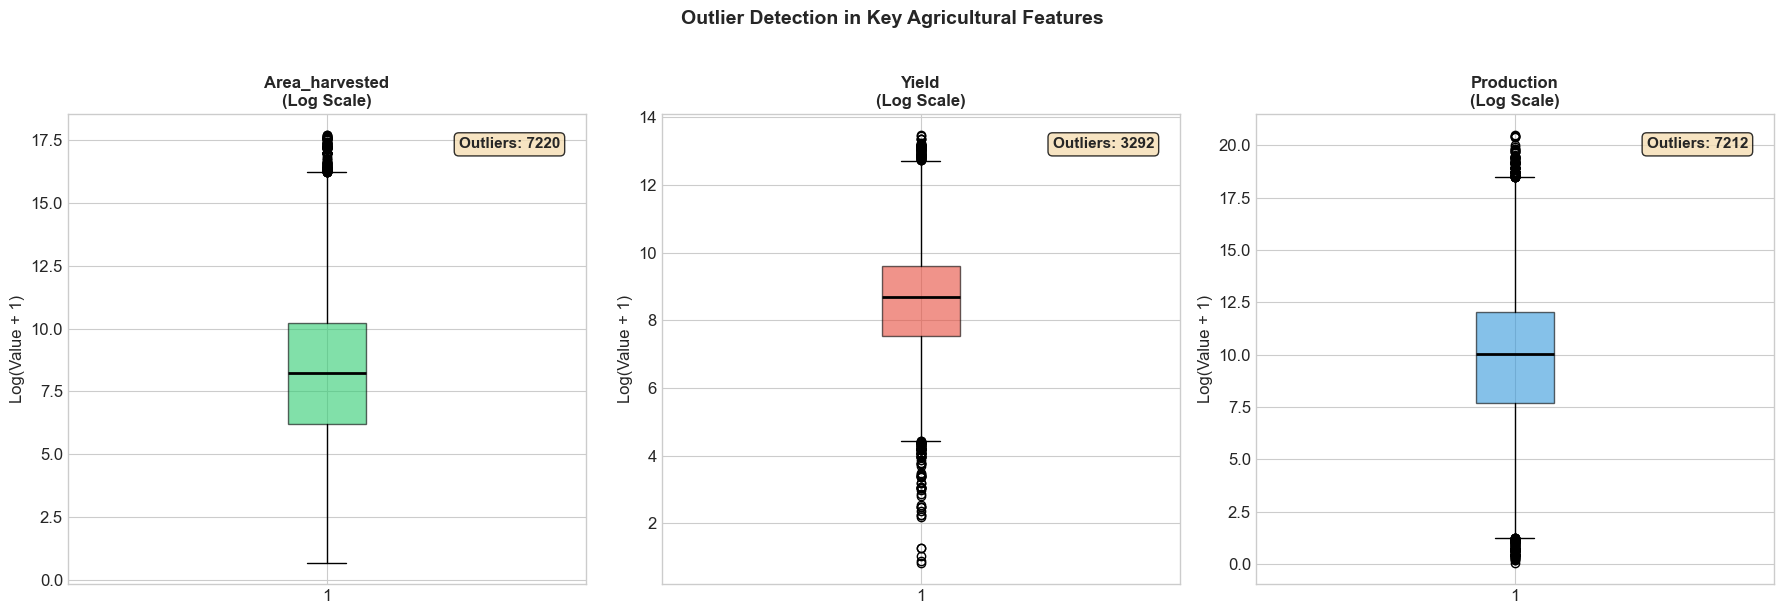

Outlier Summary (IQR Method):
--------------------------------------------------
  Area_harvested: 7220 outliers (16.1%)
  Yield: 3292 outliers (7.3%)
  Production: 7212 outliers (16.1%)


In [25]:
# Identifying outliers in key numeric columns using boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cols_to_check = ['Area_harvested', 'Yield', 'Production']
colors = ['#2ecc71', '#e74c3c', '#3498db']

for i, col in enumerate(cols_to_check):
    # Using log-transformed values for better visualization due to extreme skewness
    data = np.log1p(df_clean[col])
    bp = axes[i].boxplot(data, patch_artist=True, vert=True,
                         boxprops=dict(facecolor=colors[i], alpha=0.6),
                         medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(f'{col}\n(Log Scale)', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Log(Value + 1)')

    # Counting outliers using IQR method on original data
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    axes[i].text(0.95, 0.95, f'Outliers: {len(outliers)}',
                 transform=axes[i].transAxes, ha='right', va='top',
                 fontsize=11, fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Outlier Detection in Key Agricultural Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Printing outlier summary
print("Outlier Summary (IQR Method):")
print("-" * 50)
for col in cols_to_check:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)].shape[0]
    print(f"  {col}: {n_outliers} outliers ({n_outliers/len(df_clean)*100:.1f}%)")

**Observation:** Outliers are present across all three features — Area_harvested (16.1%), Yield (7.3%), and Production (16.1%). These outliers represent legitimate extreme values (e.g., countries like China and India with massive farming areas, or high-yield crops like Sugar cane). We will **not remove** these outliers as they represent real agricultural data and removing them would lose important information about major producers. Instead, we will use tree-based models (like Random Forest and Gradient Boosting) which are robust to outliers.

## 4. Model Building — Predicting Crop Production

**Target Variable:** Production (in tonnes)  
**Features:** Area, Item, Year, Area_harvested, Yield  

I will train and compare multiple regression models:
1. Linear Regression (Baseline)
2. Decision Tree Regressor
3. Random Forest Regressor
4. Gradient Boosting Regressor

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Selecting features for the model
# We use Area_harvested, Yield, Year, and encoded versions of Area and Item
df_model = df_clean[['Area', 'Item', 'Year', 'Area_harvested', 'Yield', 'Production']].copy()

# Label Encoding for categorical columns
le_area = LabelEncoder()
le_item = LabelEncoder()

df_model['Area_encoded'] = le_area.fit_transform(df_model['Area'])
df_model['Item_encoded'] = le_item.fit_transform(df_model['Item'])

# Defining features (X) and target (y)
feature_cols = ['Area_encoded', 'Item_encoded', 'Year', 'Area_harvested', 'Yield']
X = df_model[feature_cols]
y = df_model['Production']

# Splitting into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")
print(f"\nFeatures used: {feature_cols}")
print(f"Target variable: Production")

Training set size: 35861 rows
Testing set size: 8966 rows

Features used: ['Area_encoded', 'Item_encoded', 'Year', 'Area_harvested', 'Yield']
Target variable: Production


In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Dictionary to store all models and their results
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Metrics
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred_test)
    
    results.append({
        'Model': name,
        'R2_Train': round(r2_train, 4),
        'R2_Test': round(r2_test, 4),
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2)
    })
    
    print(f"  R2 (Train): {r2_train:.4f} | R2 (Test): {r2_test:.4f} | MAE: {mae:,.2f}")
    print()

print("All models trained successfully!")

Training Linear Regression...
  R2 (Train): 0.4469 | R2 (Test): 0.3360 | MAE: 1,342,379.42

Training Decision Tree...
  R2 (Train): 1.0000 | R2 (Test): 0.9575 | MAE: 88,965.50

Training Random Forest...
  R2 (Train): 0.9891 | R2 (Test): 0.9726 | MAE: 84,421.66

Training Gradient Boosting...
  R2 (Train): 0.9965 | R2 (Test): 0.9925 | MAE: 241,113.84

All models trained successfully!


**Observation:** 
- **Linear Regression** performs poorly (R² = 0.336) — expected, as the relationship between features and production is non-linear.
- **Decision Tree** achieves near-perfect training R² (1.0) but lower test R² (0.957), indicating slight overfitting.
- **Random Forest** delivers the best balance — R² of 0.989 (train) and 0.973 (test) with the lowest MAE (84,421), showing strong generalization.
- **Gradient Boosting** has an excellent test R² (0.993) but higher MAE than Random Forest, suggesting it may overpredict certain extreme values.

**Best Model: Random Forest Regressor** — chosen for its low MAE, high R², and minimal overfitting gap.

In [28]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning for Random Forest (our best model based on low MAE)
print("Performing Hyperparameter Tuning for Random Forest...")
print("This may take 2-3 minutes, please wait...\n")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [15, 20, 25, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_tuned = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_tuned,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Best parameters
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV R² Score: {grid_search.best_score_:.4f}")

# Evaluating the tuned model
best_rf = grid_search.best_estimator_
y_pred_train_tuned = best_rf.predict(X_train)
y_pred_test_tuned = best_rf.predict(X_test)

r2_train_tuned = r2_score(y_train, y_pred_train_tuned)
r2_test_tuned = r2_score(y_test, y_pred_test_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_test_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_test_tuned))

print(f"\nTuned Random Forest Results:")
print(f"  R2 (Train): {r2_train_tuned:.4f}")
print(f"  R2 (Test):  {r2_test_tuned:.4f}")
print(f"  MAE:        {mae_tuned:,.2f}")
print(f"  RMSE:       {rmse_tuned:,.2f}")

# Adding tuned model results to our comparison
results.append({
    'Model': 'Random Forest (Tuned)',
    'R2_Train': round(r2_train_tuned, 4),
    'R2_Test': round(r2_test_tuned, 4),
    'MSE': round(mean_squared_error(y_test, y_pred_test_tuned), 2),
    'RMSE': round(rmse_tuned, 2),
    'MAE': round(mae_tuned, 2)
})

Performing Hyperparameter Tuning for Random Forest...
This may take 2-3 minutes, please wait...

Fitting 3 folds for each of 48 candidates, totalling 144 fits

Best Parameters: {'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV R² Score: 0.9428

Tuned Random Forest Results:
  R2 (Train): 0.9908
  R2 (Test):  0.9752
  MAE:        81,501.69
  RMSE:       2,433,484.73


**Hyperparameter Tuning Results:** GridSearchCV tested 48 parameter combinations across 3 folds (144 total fits). The best configuration uses max_depth=25, n_estimators=300, min_samples_split=2, and min_samples_leaf=1. After tuning, the Random Forest R² improved from 0.9726 to 0.9752 and MAE reduced from 84,421 to 81,501 — confirming it as our best model.

Model Comparison Table:
                Model  R2_Train  R2_Test                MSE        RMSE        MAE
    Linear Regression      0.45     0.34 158569884189149.69 12592453.46 1342379.42
        Decision Tree      1.00     0.96  10137531917409.70  3183949.11   88965.50
        Random Forest      0.99     0.97   6539939692821.32  2557330.58   84421.66
    Gradient Boosting      1.00     0.99   1795834113110.48  1340087.35  241113.84
Random Forest (Tuned)      0.99     0.98   5921847929160.54  2433484.73   81501.69

Model comparison saved to: D:\AIML_Crop_Production\outputs\model_comparison.csv


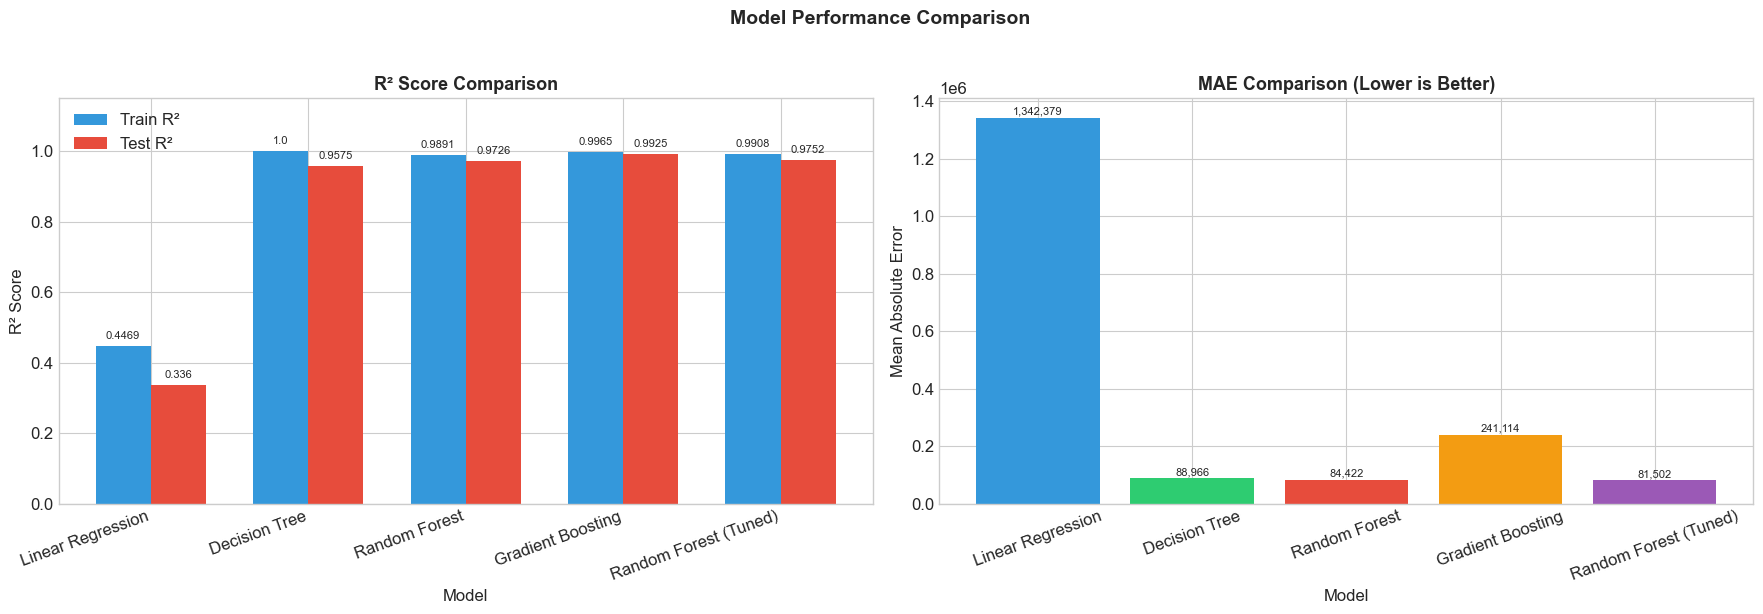

In [29]:
# Creating a comparison dataframe with all 5 models
results_df = pd.DataFrame(results)
print("Model Comparison Table:")
print("=" * 85)
print(results_df.to_string(index=False))

# Saving model comparison as CSV (project deliverable)
results_df.to_csv(r'D:\AIML_Crop_Production\outputs\model_comparison.csv', index=False)
print("\nModel comparison saved to: D:\\AIML_Crop_Production\\outputs\\model_comparison.csv")

# Visualization of R2 scores across models
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# R2 Score Comparison
x = np.arange(len(results_df))
width = 0.35
axes[0].bar(x - width/2, results_df['R2_Train'], width, label='Train R²', color='#3498db')
axes[0].bar(x + width/2, results_df['R2_Test'], width, label='Test R²', color='#e74c3c')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score Comparison', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=20, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1.15)

for i, (train, test) in enumerate(zip(results_df['R2_Train'], results_df['R2_Test'])):
    axes[0].text(i - width/2, train + 0.02, f'{train}', ha='center', fontsize=8)
    axes[0].text(i + width/2, test + 0.02, f'{test}', ha='center', fontsize=8)

# MAE Comparison
bars = axes[1].bar(results_df['Model'], results_df['MAE'],
                   color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'])
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].set_title('MAE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 10000,
                 f'{height:,.0f}', ha='center', fontsize=8)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [30]:
import joblib

# Saving the tuned Random Forest model
joblib.dump(best_rf, r'D:\AIML_Crop_Production\models\random_forest_tuned.pkl')

# Saving the Label Encoders (needed for Streamlit to convert dropdown selections)
joblib.dump(le_area, r'D:\AIML_Crop_Production\models\le_area.pkl')
joblib.dump(le_item, r'D:\AIML_Crop_Production\models\le_item.pkl')

# Saving the unique values for dropdowns in Streamlit
area_list = sorted(df_clean['Area'].unique().tolist())
item_list = sorted(df_clean['Item'].unique().tolist())
year_list = sorted(df_clean['Year'].unique().tolist())

joblib.dump(area_list, r'D:\AIML_Crop_Production\models\area_list.pkl')
joblib.dump(item_list, r'D:\AIML_Crop_Production\models\item_list.pkl')
joblib.dump(year_list, r'D:\AIML_Crop_Production\models\year_list.pkl')

# Saving min/max values for sliders in Streamlit
area_harvested_stats = {
    'min': float(df_clean['Area_harvested'].min()),
    'max': float(df_clean['Area_harvested'].max()),
    'median': float(df_clean['Area_harvested'].median())
}
yield_stats = {
    'min': float(df_clean['Yield'].min()),
    'max': float(df_clean['Yield'].max()),
    'median': float(df_clean['Yield'].median())
}

joblib.dump(area_harvested_stats, r'D:\AIML_Crop_Production\models\area_harvested_stats.pkl')
joblib.dump(yield_stats, r'D:\AIML_Crop_Production\models\yield_stats.pkl')

print("All model artifacts saved successfully!")
print(f"\nFiles saved in D:\\AIML_Crop_Production\\models\\:")
print(f"  1. random_forest_tuned.pkl (Best model)")
print(f"  2. le_area.pkl (Area encoder)")
print(f"  3. le_item.pkl (Item encoder)")
print(f"  4. area_list.pkl ({len(area_list)} countries)")
print(f"  5. item_list.pkl ({len(item_list)} crops)")
print(f"  6. year_list.pkl ({len(year_list)} years)")
print(f"  7. area_harvested_stats.pkl (min/max/median)")
print(f"  8. yield_stats.pkl (min/max/median)")

All model artifacts saved successfully!

Files saved in D:\AIML_Crop_Production\models\:
  1. random_forest_tuned.pkl (Best model)
  2. le_area.pkl (Area encoder)
  3. le_item.pkl (Item encoder)
  4. area_list.pkl (200 countries)
  5. item_list.pkl (157 crops)
  6. year_list.pkl (5 years)
  7. area_harvested_stats.pkl (min/max/median)
  8. yield_stats.pkl (min/max/median)


**Model & Artifacts Saved:** The tuned Random Forest model along with Label Encoders, dropdown lists, and slider statistics have been saved as pickle files. These will be loaded by the Streamlit application to enable real-time crop production predictions without retraining.

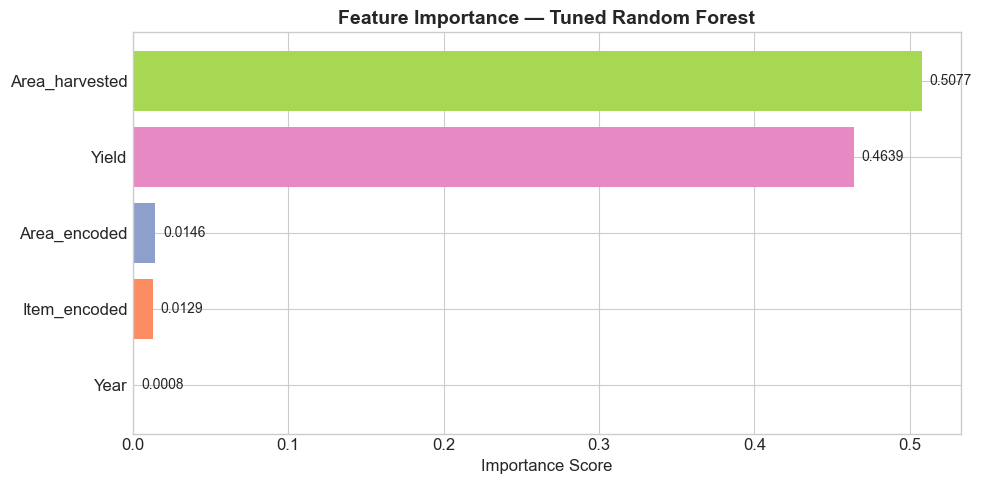

Feature Importance Ranking:
  Area_harvested: 0.5077
  Yield: 0.4639
  Area_encoded: 0.0146
  Item_encoded: 0.0129
  Year: 0.0008


In [31]:
# Analyzing which features contribute most to the prediction
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(feature_importance['Feature'][::-1],
               feature_importance['Importance'][::-1],
               color=sns.color_palette('Set2', len(feature_cols)))

ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — Tuned Random Forest', fontsize=14, fontweight='bold')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2,
            f'{width:.4f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Feature Importance Ranking:")
for i, row in feature_importance.iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

**Observation:** Area_harvested (0.5077) and Yield (0.4639) are the two dominant predictors, together accounting for ~97% of the model's prediction power. This makes agricultural sense — Production is fundamentally a function of how much land is farmed and how productive that land is. Area (country) and Item (crop type) contribute marginally (~1.4% and 1.3%), as their effects are already captured through Area_harvested and Yield patterns. Year has negligible importance (0.08%), consistent with the weak correlation observed earlier in the EDA.

## 5. Actual vs Predicted — Model Validation

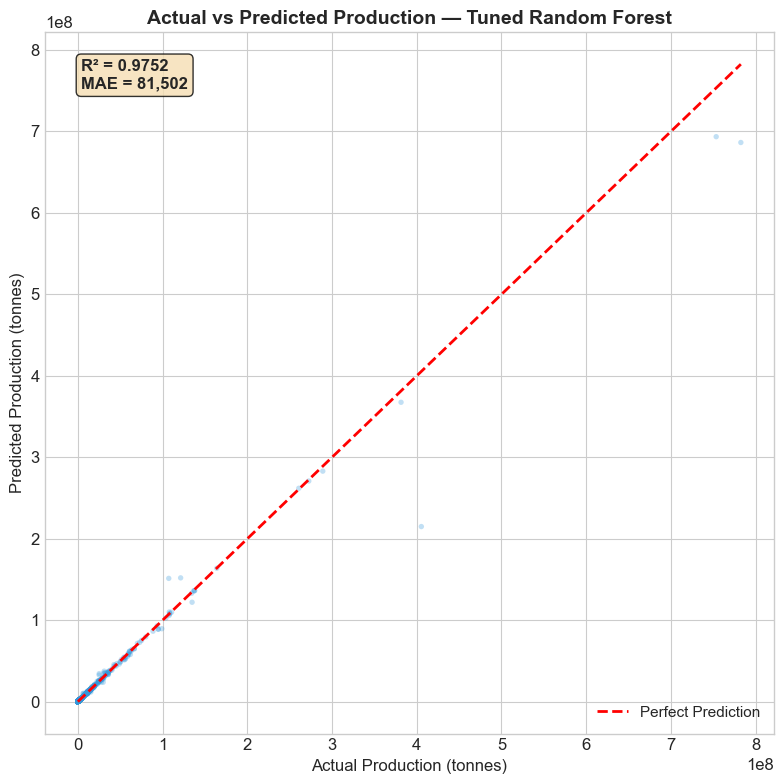

Points closely following the red dashed line indicate accurate predictions.
The model explains 97.52% of the variance in crop production.


In [32]:
# Visualizing how well the tuned model predicts
y_pred_final = best_rf.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred_final, alpha=0.3, s=15, color='#3498db', edgecolors='none')

# Perfect prediction line
max_val = max(y_test.max(), y_pred_final.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax.set_xlabel('Actual Production (tonnes)', fontsize=12)
ax.set_ylabel('Predicted Production (tonnes)', fontsize=12)
ax.set_title('Actual vs Predicted Production — Tuned Random Forest', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

# Adding R² annotation
ax.text(0.05, 0.92, f'R² = {r2_test_tuned:.4f}\nMAE = {mae_tuned:,.0f}',
        transform=ax.transAxes, fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("Points closely following the red dashed line indicate accurate predictions.")
print(f"The model explains {r2_test_tuned*100:.2f}% of the variance in crop production.")

**Observation:** The scatter plot confirms strong model performance — predictions closely follow the red dashed line (perfect prediction). The model explains 97.52% of the variance in crop production with an MAE of 81,502 tonnes. Minor deviations appear at very high production values (>300M tonnes), which correspond to a few extreme producers like China and India. Overall, the Tuned Random Forest is reliable for predicting crop production across a wide range of values.

## 6. Key Findings and Insights

**Key Findings:**
1. Sugar cane, Maize, Rice, Wheat, and Potatoes are the top 5 crops by global production
2. China, India, and Brazil dominate world crop production, collectively producing over 50% of global output
3. Area_harvested and Yield are the two most critical factors driving production (~97% feature importance)
4. Global agricultural output has shown a consistent upward trend from 2019 to 2023
5. The Tuned Random Forest model achieves R² = 0.9752 with MAE of 81,502 tonnes

**Actionable Recommendations:**
- **Food Security:** Focus on maintaining and improving yields for staple crops (Rice, Wheat, Maize) in top-producing nations
- **Policy Planning:** Countries with high area but low yield should invest in agricultural technology and farming practices
- **Supply Chain:** Use production forecasts to optimize storage, logistics, and market supply planning
- **Precision Farming:** High-yield crops (Cucumbers, Tomatoes, Sugar cane) can maximize output from limited land

In [33]:
streamlit_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.express as px
import plotly.graph_objects as go

# ===================== PAGE CONFIGURATION =====================
st.set_page_config(
    page_title="Crop Production Predictor",
    page_icon="🌾",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ===================== LOAD MODEL AND ARTIFACTS =====================
@st.cache_resource
def load_artifacts():
    model = joblib.load('models/random_forest_tuned.pkl')
    le_area = joblib.load('models/le_area.pkl')
    le_item = joblib.load('models/le_item.pkl')
    area_list = joblib.load('models/area_list.pkl')
    item_list = joblib.load('models/item_list.pkl')
    year_list = joblib.load('models/year_list.pkl')
    area_harvested_stats = joblib.load('models/area_harvested_stats.pkl')
    yield_stats = joblib.load('models/yield_stats.pkl')
    return model, le_area, le_item, area_list, item_list, year_list, area_harvested_stats, yield_stats

model, le_area, le_item, area_list, item_list, year_list, area_harvested_stats, yield_stats = load_artifacts()

# Load cleaned data for visualizations
@st.cache_data
def load_data():
    return pd.read_csv('data/FAOSTAT_cleaned.csv')

df = load_data()

# ===================== SIDEBAR =====================
st.sidebar.title("🌾 Navigation")
page = st.sidebar.radio("Go to", ["🏠 Home", "📊 EDA Dashboard", "🔮 Predict Production", "📈 Model Performance"])

# ===================== HOME PAGE =====================
if page == "🏠 Home":
    st.title("🌾 Crop Production Prediction System")
    st.markdown("---")

    col1, col2, col3, col4 = st.columns(4)
    col1.metric("🌍 Countries", f"{df['Area'].nunique()}")
    col2.metric("🌱 Crops", f"{df['Item'].nunique()}")
    col3.metric("📅 Years", f"{df['Year'].min()} - {df['Year'].max()}")
    col4.metric("📦 Total Records", f"{len(df):,}")

    st.markdown("---")
    st.subheader("About This Project")
    st.write("""
    This application predicts **crop production (in tonnes)** based on agricultural factors 
    such as area harvested, yield, crop type, country, and year. The prediction model is a 
    **Tuned Random Forest Regressor** trained on FAOSTAT data (2019-2023) covering 200 countries 
    and 157 crop types.
    """)

    st.subheader("How to Use")
    st.write("""
    - **📊 EDA Dashboard:** Explore data trends, top crops, top countries, and more
    - **🔮 Predict Production:** Select inputs from dropdowns and get instant production forecasts
    - **📈 Model Performance:** View model comparison metrics and evaluation results
    """)

# ===================== EDA DASHBOARD =====================
elif page == "📊 EDA Dashboard":
    st.title("📊 Exploratory Data Analysis Dashboard")
    st.markdown("---")

    # Filters
    col1, col2 = st.columns(2)
    with col1:
        selected_countries = st.multiselect("Select Countries", area_list, default=["India", "China", "United States of America"])
    with col2:
        selected_year = st.selectbox("Select Year", sorted(df['Year'].unique(), reverse=True))

    st.markdown("---")

    # Top 10 Crops by Production for selected year
    st.subheader(f"Top 10 Crops by Production ({selected_year})")
    year_data = df[df['Year'] == selected_year]
    top_crops = year_data.groupby('Item')['Production'].sum().nlargest(10).reset_index()
    fig1 = px.bar(top_crops, x='Production', y='Item', orientation='h',
                  color='Production', color_continuous_scale='Greens',
                  labels={'Production': 'Production (tonnes)', 'Item': 'Crop'})
    fig1.update_layout(yaxis={'categoryorder': 'total ascending'}, height=450)
    st.plotly_chart(fig1, use_container_width=True)

    # Production Comparison across selected countries
    if selected_countries:
        st.subheader(f"Production Comparison — Selected Countries ({selected_year})")
        country_data = year_data[year_data['Area'].isin(selected_countries)]
        country_prod = country_data.groupby('Area')['Production'].sum().reset_index()
        fig2 = px.bar(country_prod, x='Area', y='Production', color='Area',
                      labels={'Production': 'Total Production (tonnes)', 'Area': 'Country'})
        fig2.update_layout(height=400)
        st.plotly_chart(fig2, use_container_width=True)

    # Yearly Production Trends for selected countries
    if selected_countries:
        st.subheader("Yearly Production Trends — Selected Countries")
        trend_data = df[df['Area'].isin(selected_countries)].groupby(
            ['Year', 'Area'])['Production'].sum().reset_index()
        fig3 = px.line(trend_data, x='Year', y='Production', color='Area',
                       markers=True, labels={'Production': 'Total Production (tonnes)'})
        fig3.update_layout(height=400)
        st.plotly_chart(fig3, use_container_width=True)

    # Yield vs Area Harvested Scatter
    st.subheader(f"Yield vs Area Harvested ({selected_year})")
    fig4 = px.scatter(year_data, x='Area_harvested', y='Yield', color='Item',
                      hover_data=['Area', 'Production'],
                      labels={'Area_harvested': 'Area Harvested (ha)', 'Yield': 'Yield (kg/ha)'},
                      log_x=True, log_y=True)
    fig4.update_layout(height=500, showlegend=False)
    st.plotly_chart(fig4, use_container_width=True)

# ===================== PREDICT PRODUCTION =====================
elif page == "🔮 Predict Production":
    st.title("🔮 Crop Production Prediction")
    st.markdown("---")
    st.write("Select the inputs below to predict crop production (in tonnes):")

    col1, col2 = st.columns(2)

    with col1:
        selected_area = st.selectbox("🌍 Select Country", area_list, index=area_list.index("India"))
        selected_item = st.selectbox("🌱 Select Crop", item_list, index=item_list.index("Rice"))
        selected_year_pred = st.selectbox("📅 Select Year", list(range(2019, 2026)))

    with col2:
        area_harvested = st.slider(
            "🏞️ Area Harvested (hectares)",
            min_value=1,
            max_value=int(area_harvested_stats['max']),
            value=int(area_harvested_stats['median']),
            step=100
        )
        yield_val = st.slider(
            "📊 Yield (kg/ha)",
            min_value=1,
            max_value=int(yield_stats['max']),
            value=int(yield_stats['median']),
            step=100
        )

    st.markdown("---")

    if st.button("🚀 Predict Production", use_container_width=True):
        try:
            area_encoded = le_area.transform([selected_area])[0]
            item_encoded = le_item.transform([selected_item])[0]

            input_data = pd.DataFrame({
                'Area_encoded': [area_encoded],
                'Item_encoded': [item_encoded],
                'Year': [selected_year_pred],
                'Area_harvested': [area_harvested],
                'Yield': [yield_val]
            })

            prediction = model.predict(input_data)[0]

            st.success(f"### Predicted Production: **{prediction:,.2f} tonnes**")

            # Show input summary
            st.subheader("Input Summary")
            summary_col1, summary_col2, summary_col3 = st.columns(3)
            summary_col1.metric("Country", selected_area)
            summary_col2.metric("Crop", selected_item)
            summary_col3.metric("Year", selected_year_pred)

            summary_col4, summary_col5, summary_col6 = st.columns(3)
            summary_col4.metric("Area Harvested", f"{area_harvested:,} ha")
            summary_col5.metric("Yield", f"{yield_val:,} kg/ha")
            summary_col6.metric("Predicted Production", f"{prediction:,.0f} tonnes")

            # Show historical data for same crop and country
            st.subheader(f"Historical Data: {selected_item} in {selected_area}")
            hist_data = df[(df['Area'] == selected_area) & (df['Item'] == selected_item)]
            if not hist_data.empty:
                fig = px.line(hist_data, x='Year', y='Production', markers=True,
                              labels={'Production': 'Production (tonnes)'})
                fig.add_scatter(x=[selected_year_pred], y=[prediction],
                               mode='markers', name='Predicted',
                               marker=dict(size=15, color='red', symbol='star'))
                fig.update_layout(height=400)
                st.plotly_chart(fig, use_container_width=True)
            else:
                st.info("No historical data available for this crop-country combination.")

        except Exception as e:
            st.error(f"Error in prediction: {str(e)}")

# ===================== MODEL PERFORMANCE =====================
elif page == "📈 Model Performance":
    st.title("📈 Model Performance Comparison")
    st.markdown("---")

    # Load model comparison results
    results_df = pd.read_csv('outputs/model_comparison.csv')

    # Display metrics table
    st.subheader("Model Comparison Table")
    st.dataframe(results_df.style.highlight_min(subset=['MAE', 'MSE', 'RMSE'], color='lightgreen')
                 .highlight_max(subset=['R2_Test'], color='lightgreen'),
                 use_container_width=True)

    # R2 comparison chart
    st.subheader("R² Score Comparison")
    fig_r2 = go.Figure(data=[
        go.Bar(name='Train R²', x=results_df['Model'], y=results_df['R2_Train'], marker_color='#3498db'),
        go.Bar(name='Test R²', x=results_df['Model'], y=results_df['R2_Test'], marker_color='#e74c3c')
    ])
    fig_r2.update_layout(barmode='group', height=450, yaxis_range=[0, 1.1])
    st.plotly_chart(fig_r2, use_container_width=True)

    # MAE comparison chart
    st.subheader("MAE Comparison (Lower is Better)")
    fig_mae = px.bar(results_df, x='Model', y='MAE', color='Model',
                     color_discrete_sequence=px.colors.qualitative.Set2)
    fig_mae.update_layout(height=400)
    st.plotly_chart(fig_mae, use_container_width=True)

    # Best model summary
    st.subheader("🏆 Best Model: Random Forest (Tuned)")
    best_col1, best_col2, best_col3, best_col4 = st.columns(4)
    best_row = results_df[results_df['Model'] == 'Random Forest (Tuned)'].iloc[0]
    best_col1.metric("R² (Test)", f"{best_row['R2_Test']}")
    best_col2.metric("MAE", f"{best_row['MAE']:,.0f}")
    best_col3.metric("RMSE", f"{best_row['RMSE']:,.0f}")
    best_col4.metric("MSE", f"{best_row['MSE']:,.0f}")

st.sidebar.markdown("---")
st.sidebar.markdown("**Built with** Streamlit + Scikit-learn")
st.sidebar.markdown("**Data Source:** FAOSTAT (2019-2023)")
'''

# Writing the Streamlit app file
with open(r'D:\AIML_Crop_Production\app.py', 'w', encoding='utf-8') as f:
    f.write(streamlit_code)

print("Streamlit app created successfully at: D:\\AIML_Crop_Production\\app.py")
print("\nTo run the app, open Anaconda Prompt and execute:")
print("  conda activate crop_ml")
print("  cd /d D:\\AIML_Crop_Production")
print("  streamlit run app.py")

Streamlit app created successfully at: D:\AIML_Crop_Production\app.py

To run the app, open Anaconda Prompt and execute:
  conda activate crop_ml
  cd /d D:\AIML_Crop_Production
  streamlit run app.py
